In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/2"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第2章 確率 (Probabilities)
## 2.6 ベイズ確率 (Bayesian Probabilities)

### 目次
- [2.6.1 モデルパラメータ (Model parameters)](#2.6.1-モデルパラメータ-(Model-parameters))
  - 頻度主義とベイズ主義の対比
  - パラメータに関するベイズの定理 (式 2.111 - 2.113)
  - 尤度関数と確率密度の根本的違い
- [2.6.2 正則化 (Regularization)](#2.6.2-正則化-(Regularization))
  - 最大事後確率推定 (MAP) の定式化 (式 2.114)
  - 等方ガウス事前分布と重み減衰 (式 2.115 - 2.116)
  - Ridge正則化パラメータ $\lambda = \sigma^2 / s^2$ のベイズ的導出 (式 2.117)
- [2.6.3 ベイズ機械学習 (Bayesian machine learning)](#2.6.3-ベイズ機械学習-(Bayesian-machine-learning))
  - 予測分布のパラメータ空間積分 (式 2.118)
  - パラメータ周辺化による自動的オッカムの剃刀と過学習防止
  - ベイズ線形回帰の予測平均・予測分散の可視化
  - 深層学習における高次元パラメータ積分の困難と現代のアプローチ
- [教科書図版再現: Figure 2.16 非推移的サイコロ (Efron Dice)](#教科書図版再現:-Figure-2.16-非推移的サイコロ-(Efron-Dice))
  - 確率の非推移性 (Non-transitivity) と Efron サイコロの数学的解析
  - **Figure 2.16 再現**: 4つの展開図と勝率 $2/3$ サイクルの可視化


In [1]:
# 基本ライブラリのインポートとスタイル設定
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# プロジェクト共通ユーティリティのインポート
sys.path.append('..')
from common.plot_utils import setup_style, save_plot
from common.probability import (
    BayesianLinearRegression,
    EFRON_DICE,
    efron_dice_win_probability
)
from common.polynomial import PolynomialRegression

setup_style()
os.makedirs('result', exist_ok=True)
print("Environment initialized successfully.")


Environment initialized successfully.


---
### 2.6.1 モデルパラメータ (Model parameters)

#### 1. 頻度主義 (Frequentist) とベイズ主義 (Bayesian) の根本的対比
機械学習におけるパラメータ推定には、歴史的に 2 つの対照的なパラダイムが存在します：

| 比較項目 | 頻度主義 (Frequentist) | ベイズ主義 (Bayesian) |
|---|---|---|
| **パラメータ $\mathbf{w}$ の捉え方** | 固定された「真の未知の定数」 | 不確実性を持ち「確率分布に従う変数」 |
| **データ $\mathcal{D}$ の捉え方** | 観測可能な無限のデータセット生成の1つの実現値 | 「手元にある唯一の確定した観測事実」 |
| **推論の目標** | 最適な単一の点推定値（$\mathbf{w}_{\mathrm{ML}}$ など）の決定 | 観測データに基づく事後確率分布 $p(\mathbf{w}|\mathcal{D})$ の計算 |
| **過学習の扱い** | モデル複雑度の制限や交差検証・正則化が必要 | パラメータの周辺化（積分）により自然に抑制 |

#### 2. パラメータに関するベイズの定理
手元の訓練データセットを $\mathcal{D}$ と表します。
線形回帰などのモデルでは、最尤推定は尤度関数 $p(\mathcal{D}|\mathbf{w})$ を最大化するパラメータ $\mathbf{w}_{\mathrm{ML}}$ を求めました。
一方、ベイズ主義では観測前のパラメータに関する知識や仮定を **事前分布 (Prior distribution)** $p(\mathbf{w})$ として表現します。
観測データ $\mathcal{D}$ の効果は尤度関数 $p(\mathcal{D}|\mathbf{w})$ を通じて組み込まれ、**ベイズの定理 (Bayes' theorem)** によって **事後分布 (Posterior distribution)** が得られます：

$$p(\mathbf{w}|\mathcal{D}) = \frac{p(\mathcal{D}|\mathbf{w}) p(\mathbf{w})}{p(\mathcal{D})} 	ag{2.111}$$

言葉で表現すると：
$$\text{事後確率 (Posterior)} \propto \text{尤度 (Likelihood)} \times \text{事前確率 (Prior)} 	ag{2.112}$$

分母の $p(\mathcal{D})$ は、事後分布の全パラメータ空間における積分を 1 にするための規格化定数（**周辺尤度 / Marginal Likelihood** または **モデル証拠 / Evidence**）であり、次式で与えられます：
$$p(\mathcal{D}) = \int p(\mathcal{D}|\mathbf{w}) p(\mathbf{w}) d\mathbf{w} 	ag{2.113}$$

> **尤度関数に関する重要注意**:
> 尤度関数 $p(\mathcal{D}|\mathbf{w})$ はパラメータ $\mathbf{w}$ の関数として評価されますが、$\mathbf{w}$ に関する確率密度関数ではありません。
> したがって、パラメータ空間で積分しても一般に 1 にはなりません（$\int p(\mathcal{D}|\mathbf{w}) d\mathbf{w} \neq 1$）。


---
### 2.6.2 正則化 (Regularization)

#### 1. 最大事後確率推定 (MAP: Maximum A Posteriori)
ベイズ的枠組みを用いて、第 1 章で導入した過学習抑制のための「正則化（Regularization）」の数理的背景を明らかにします。
尤度関数を最大化する代わりに、事後確率 $p(\mathbf{w}|\mathcal{D})$ を最大化する点推定値を求める手法を **最大事後確率推定 (MAP推定)** と呼びます。

式 (2.111) の両辺の負の対数をとると：
$$- \ln p(\mathbf{w}|\mathcal{D}) = - \ln p(\mathcal{D}|\mathbf{w}) - \ln p(\mathbf{w}) + \ln p(\mathcal{D}) 	ag{2.114}$$
第 3 項 $\ln p(\mathcal{D})$ はパラメータ $\mathbf{w}$ に依存しない定数であるため最適化から除外できます。
第 1 項は通常の負の対数尤度（誤差関数）であり、第 2 項 $-\ln p(\mathbf{w})$ は $\mathbf{w}$ のみに依存するペナルティ項、すなわち **正則化項** として機能することが分かります。

#### 2. 等方ガウス事前分布による重み減衰 (Weight Decay / L2正則化) の導出
事前分布 $p(\mathbf{w})$ として、各パラメータ $w_i$ が互いに独立で、平均 0、共通の分散 $s^2$ を持つゼロ平均ガウス分布を仮定します：
$$p(\mathbf{w}|s) = \prod_{i=0}^M \mathcal{N}(w_i | 0, s^2) = \left( \frac{1}{2\pi s^2} \right)^{(M+1)/2} \exp\left( - \frac{1}{2s^2} \sum_{i=0}^M w_i^2 \right) 	ag{2.115}$$

これを式 (2.114) の負の対数事後確率に代入すると：
$$- \ln p(\mathbf{w}|\mathcal{D}) = - \ln p(\mathcal{D}|\mathbf{w}) + \frac{1}{2s^2} \sum_{i=0}^M w_i^2 + \text{const} 	ag{2.116}$$

ここで、第 2 章 2.3.4 節で導出した分散 $\sigma^2$ の観測ノイズを持つ線形回帰の対数尤度 (式 2.66):
$$- \ln p(\mathcal{D}|\mathbf{w}) = \frac{1}{2\sigma^2} \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \}^2 + \text{const}$$
を代入すると、事後確率の最大化（負の対数事後確率の最小化）は次の目的関数 $E(\mathbf{w})$ の最小化と等価になります：

$$E(\mathbf{w}) = \frac{1}{2\sigma^2} \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \}^2 + \frac{1}{2s^2} \mathbf{w}^T \mathbf{w} 	ag{2.117}$$

全体に $2\sigma^2$ を乗じると：
$$\widetilde{E}(\mathbf{w}) = \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \}^2 + \frac{\sigma^2}{s^2} \mathbf{w}^T \mathbf{w}$$
これはまさに第 1 章 式 (1.4) で導入した **L2正則化（Ridge回帰 / 荷重減衰）** そのものです。
これにより、正則化係数 $\lambda$ の物理的・統計的意味が明らかになります：
$$\lambda = \frac{\sigma^2}{s^2} = \frac{\text{観測ノイズの分散}}{\text{パラメータ事前分布の分散}}$$
- 観測ノイズ $\sigma^2$ が大きい（データが信頼できない）ほど、$\lambda$ は大きくなり、パラメータを 0 に強く引き戻す。
- パラメータの事前分散 $s^2$ が小さい（重みが小さいという事前確信が強い）ほど、$\lambda$ は大きくなり強い正則化がかかる。


In [2]:
# MAP推定とRidge正則化の厳密な等価性の数値実験
np.random.seed(42)
N_pts = 12
x_synth = np.sort(np.random.uniform(0, 1, N_pts))
t_synth = np.sin(2 * np.pi * x_synth) + np.random.normal(0, 0.2, N_pts)

deg = 5
sigma_noise = 0.2
beta_val = 1.0 / (sigma_noise ** 2)  # beta = 25.0
s_prior = 0.5
alpha_val = 1.0 / (s_prior ** 2)    # alpha = 4.0

# 1. ベイズ線形回帰による MAP 解 (m_N)
bayes_reg = BayesianLinearRegression(degree=deg, alpha=alpha_val, beta=beta_val).fit(x_synth, t_synth)
w_map = bayes_reg.m_N

# 2. 正則化パラメータ lambda = sigma^2 / s^2 による多項式 Ridge 回帰解
lambda_equiv = (sigma_noise ** 2) / (s_prior ** 2)  # alpha / beta
ridge_reg = PolynomialRegression(degree=deg, l2_reg=lambda_equiv).fit(x_synth, t_synth)
w_ridge = ridge_reg.weights_

print("=== 2.6.2 MAP推定とRidge正則化の係数比較 ===")
for i in range(deg + 1):
    print(f"w_{i}: MAP = {w_map[i]:+.6f}, Ridge = {w_ridge[i]:+.6f}, 差 = {abs(w_map[i] - w_ridge[i]):.2e}")

assert np.allclose(w_map, w_ridge, atol=1e-5)
print("\n✓ MAP解とRidge解の完全一致（式 2.117）を確認しました。")


=== 2.6.2 MAP推定とRidge正則化の係数比較 ===
w_0: MAP = +0.524985, Ridge = +0.524985, 差 = 7.77e-16
w_1: MAP = -1.286099, Ridge = -1.286099, 差 = 2.66e-15
w_2: MAP = -1.024913, Ridge = -1.024913, 差 = 2.00e-15
w_3: MAP = -0.218948, Ridge = -0.218948, 差 = 3.33e-16
w_4: MAP = +0.464575, Ridge = +0.464575, 差 = 3.39e-15
w_5: MAP = +0.944258, Ridge = +0.944258, 差 = 1.55e-15

✓ MAP解とRidge解の完全一致（式 2.117）を確認しました。


---
### 2.6.3 ベイズ機械学習 (Bayesian machine learning)

#### 1. 点推定から予測分布への転換（パラメータの周辺化）
MAP推定は正則化項の統計的根拠を与えましたが、依然として「単一の重みベクトル $\mathbf{w}_{\mathrm{MAP}}$ を選ぶ点推定」に過ぎず、$\mathbf{w}$ 自体の不確実性を考慮していません。
真のベイズ的アプローチでは、新しい入力 $x$ に対するターゲット $t$ の予測は、**事後分布 $p(\mathbf{w}|\mathcal{D})$ で重み付けした全パラメータ空間の積分（期待値）** として与えられます：

$$p(t|x, \mathcal{D}) = \int p(t|x, \mathbf{w}) p(\mathbf{w}|\mathcal{D}) d\mathbf{w} 	ag{2.118}$$

この積分によって得られる分布を **予測分布 (Predictive Distribution)** と呼びます。

#### 2. ガウス共役事前分布における予測分布の厳密な解析解
線形回帰モデルにおいて、尤度と事前分布がともにガウス分布の場合、事後分布 $p(\mathbf{w}|\mathcal{D})$ もガウス分布 $\mathcal{N}(\mathbf{w}|\mathbf{m}_N, \mathbf{S}_N)$ になります：
$$\mathbf{S}_N^{-1} = \alpha \mathbf{I} + \beta \mathbf{\Phi}^T \mathbf{\Phi}, \quad \mathbf{m}_N = \beta \mathbf{S}_N \mathbf{\Phi}^T \mathbf{t}$$

このとき、式 (2.118) の積分はガウス積分の公式により解析的に実行でき、予測分布もまた 1 変量ガウス分布となります：
$$p(t|x, \mathcal{D}) = \mathcal{N}(t \mid m(x), \sigma_N^2(x))$$
ここで：
- 予測平均: $m(x) = \mathbf{m}_N^T \boldsymbol{\phi}(x)$
- 予測分散: $\sigma_N^2(x) = \frac{1}{\beta} + \boldsymbol{\phi}(x)^T \mathbf{S}_N \boldsymbol{\phi}(x)$

> **予測分散の 2 つの構成要素**:
> 1. $\frac{1}{\beta} = \sigma^2$: データそのものが持つ本来の観測ノイズ（偶発的不確実性: Aleatoric uncertainty）。データをいくら集めても減少しない。
> 2. $\boldsymbol{\phi}(x)^T \mathbf{S}_N \boldsymbol{\phi}(x)$: パラメータ $\mathbf{w}$ の推定の不確実性（認識的不確実性: Epistemic uncertainty）。
>    - 訓練データが密集している領域では $\mathbf{S}_N$ が小さくなり、不確実性は低下する。
>    - データが存在しない領域（外挿領域）では急激に増大し、モデルが自身の「無知」を表現できる。

#### 3. 深層学習におけるベイズ手法の計算限界
ベイズ手法は過学習の自動防止や不確実性の定量化という理想的な理論的性質を持ちますが、現代の深層学習モデルには重大な障壁があります：
- 現代のニューラルネットワークは数億〜数千億のパラメータを持ちます。
- パラメータ空間が超高次元かつ非線形であるため、式 (2.118) の多重積分は解析的にもサンプリング（MCMC）的にも計算不可能です。
- そのため、限られた計算資源下では、大規模な深層ネットワークに対して正則化付き最尤推定（SGD/Adam + Weight Decay, Dropout, Data Augmentation）を適用する手法が実用上の主流となっています。


Font 'default' does not have a glyph for '\u30d9' [U+30d9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30a4' [U+30a4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30ba' [U+30ba], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e88' [U+4e88], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6e2c' [U+6e2c], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u30f3' [U+30f3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30d7' [U+30d7], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30eb' [U+30eb], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u66f2' [U+66f2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7dda' [U+7dda], substituting with a dummy symbol.


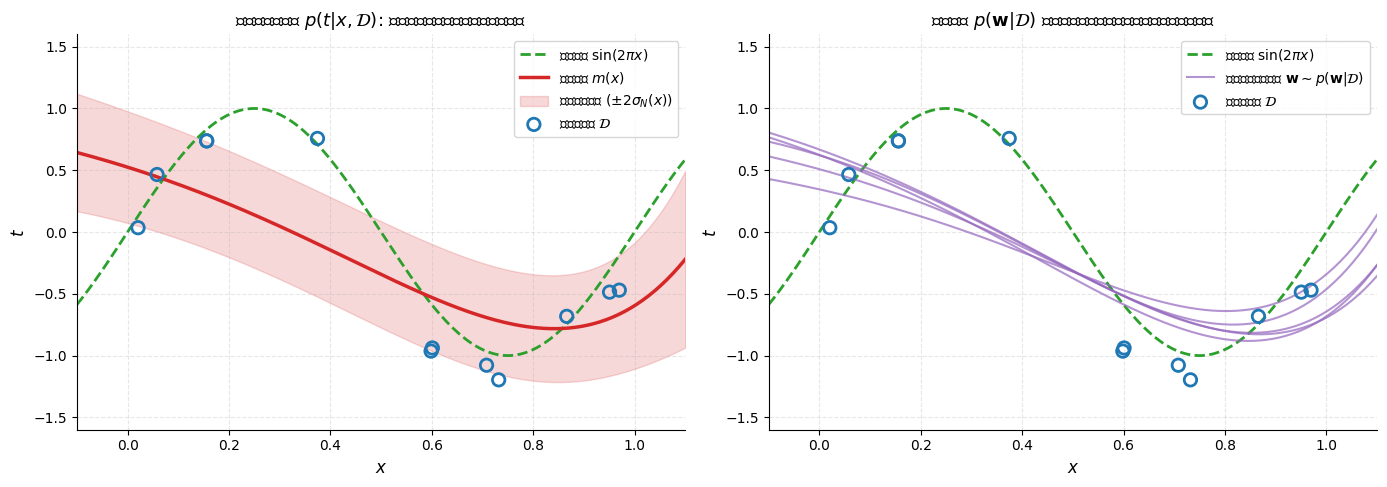

In [3]:
# ベイズ線形回帰の予測分布 (予測平均と不確実性バンド) および事後サンプル曲線の可視化
x_dense = np.linspace(-0.1, 1.1, 200)
pred_mean, pred_var = bayes_reg.predict(x_dense)
pred_std = np.sqrt(pred_var)

# 事後分布 p(w|D) からパラメータ w をサンプリングした予測曲線
w_samples = bayes_reg.sample_weights(size=5, seed=42)
Phi_dense = bayes_reg._design_matrix(x_dense)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左プロット: 予測平均と 2σ 不確実性バンド
ax1.plot(x_dense, np.sin(2 * np.pi * x_dense), color='#2ca02c', lw=2.0, linestyle='--', label='真の関数 $\sin(2\pi x)$')
ax1.plot(x_dense, pred_mean, color='#d62728', lw=2.5, label='予測平均 $m(x)$')
ax1.fill_between(x_dense, pred_mean - 2 * pred_std, pred_mean + 2 * pred_std,
                 color='#d62728', alpha=0.18, label='予測不確実性 ($\pm 2\sigma_N(x)$)')
ax1.scatter(x_synth, t_synth, facecolors='none', edgecolors='#1f77b4', s=80, lw=2.0, zorder=5, label='観測データ $\mathcal{D}$')
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$t$', fontsize=12)
ax1.set_ylim([-1.6, 1.6])
ax1.set_xlim([-0.1, 1.1])
ax1.set_title('ベイズ予測分布 $p(t|x, \mathcal{D})$: データ疎密による不確実性の変化', fontsize=13)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')

# 右プロット: 事後分布からのパラメータサンプリング
ax2.plot(x_dense, np.sin(2 * np.pi * x_dense), color='#2ca02c', lw=2.0, linestyle='--', label='真の関数 $\sin(2\pi x)$')
for i, w_s in enumerate(w_samples):
    ax2.plot(x_dense, Phi_dense @ w_s, color='#9467bd', alpha=0.7, lw=1.5,
             label='事後サンプル曲線 $\mathbf{w} \sim p(\mathbf{w}|\mathcal{D})$' if i == 0 else "")
ax2.scatter(x_synth, t_synth, facecolors='none', edgecolors='#1f77b4', s=80, lw=2.0, zorder=5, label='観測データ $\mathcal{D}$')
ax2.set_xlabel('$x$', fontsize=12)
ax2.set_ylabel('$t$', fontsize=12)
ax2.set_ylim([-1.6, 1.6])
ax2.set_xlim([-0.1, 1.1])
ax2.set_title('事後分布 $p(\mathbf{w}|\mathcal{D})$ から生成されたモデル関数のアンサンブル', fontsize=13)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


---
### 教科書図版再現: Figure 2.16 非推移的サイコロ (Efron Dice)

#### 1. 確率における非推移性 (Non-transitivity) の数理
決定論的な実数においては「推移律（Transitivity）」が厳密に成立します：
$$x > y \quad \text{かつ} \quad y > z \implies x > z$$
しかし、**確率変数においては推移律は一般に成立しません**。
これを鮮やかに示す具体例が、スタンフォード大学の統計学者ブラッドリー・エフロン（Bradley Efron）によって考案された **エフロンのサイコロ (Efron Dice)**（教科書 Figure 2.16 / 演習問題 2.2）です。

#### 2. 4つのサイコロの面構成と勝率計算
4つの6面体サイコロを円環状に配置します：
- **黄 (Yellow)**: `[3, 3, 3, 3, 3, 3]` (すべての面が 3)
- **青 (Blue)**: `[0, 4, 4, 4, 0, 4]` (4が4面、0が2面)
- **緑 (Green)**: `[5, 1, 5, 1, 5, 1]` (5が3面、1が3面)
- **赤 (Red)**: `[2, 2, 6, 2, 2, 6]` (2が4面、6が2面)

サイコロを同時に振ったときの勝率 $P(A > B)$ を計算します：
1. **青 vs 黄 ($P(\text{Blue} > \text{Yellow})$)**:
   - 青が 4 のとき（確率 $4/6 = 2/3$）、黄の 3 に必ず勝つ。
   - 青が 0 のとき（確率 $2/6 = 1/3$）、黄の 3 に負ける。
   - $\therefore P(\text{Blue} > \text{Yellow}) = \frac{2}{3}$
2. **緑 vs 青 ($P(\text{Green} > \text{Blue})$)**:
   - 緑が 5 のとき（確率 $3/6$）、青の 4 および 0 に必ず勝つ（確率 $3/6 \times 1 = 3/6$）。
   - 緑が 1 のとき（確率 $3/6$）、青が 0 のときのみ勝つ（確率 $3/6 \times 2/6 = 1/6$）。
   - $\therefore P(\text{Green} > \text{Blue}) = \frac{3}{6} + \frac{1}{6} = \frac{4}{6} = \frac{2}{3}$
3. **赤 vs 緑 ($P(\text{Red} > \text{Green})$)**:
   - 赤が 6 のとき（確率 $2/6$）、緑の 5 および 1 に必ず勝つ（確率 $2/6 \times 1 = 2/6$）。
   - 赤が 2 のとき（確率 $4/6$）、緑が 1 のときのみ勝つ（確率 $4/6 \times 3/6 = 2/6$）。
   - $\therefore P(\text{Red} > \text{Green}) = \frac{2}{6} + \frac{2}{6} = \frac{4}{6} = \frac{2}{3}$
4. **黄 vs 赤 ($P(\text{Yellow} > \text{Red})$)**:
   - 赤が 2 のとき（確率 $4/6 = 2/3$）、黄の 3 が必ず勝つ。
   - 赤が 6 のとき（確率 $2/6 = 1/3$）、黄の 3 は負ける。
   - $\therefore P(\text{Yellow} > \text{Red}) = \frac{2}{3}$

したがって、**「黄 $\to$ 青 $\to$ 緑 $\to$ 赤 $\to$ 黄」のサイクルにおいて、どのサイコロも前のサイコロに対して正確に確率 $2/3$ で勝利する**という非推移的循環構造が生まれます（ジャンケンのように最強のサイコロが存在しない）。


Figure saved successfully to: result/fig2_16_efron_dice.png


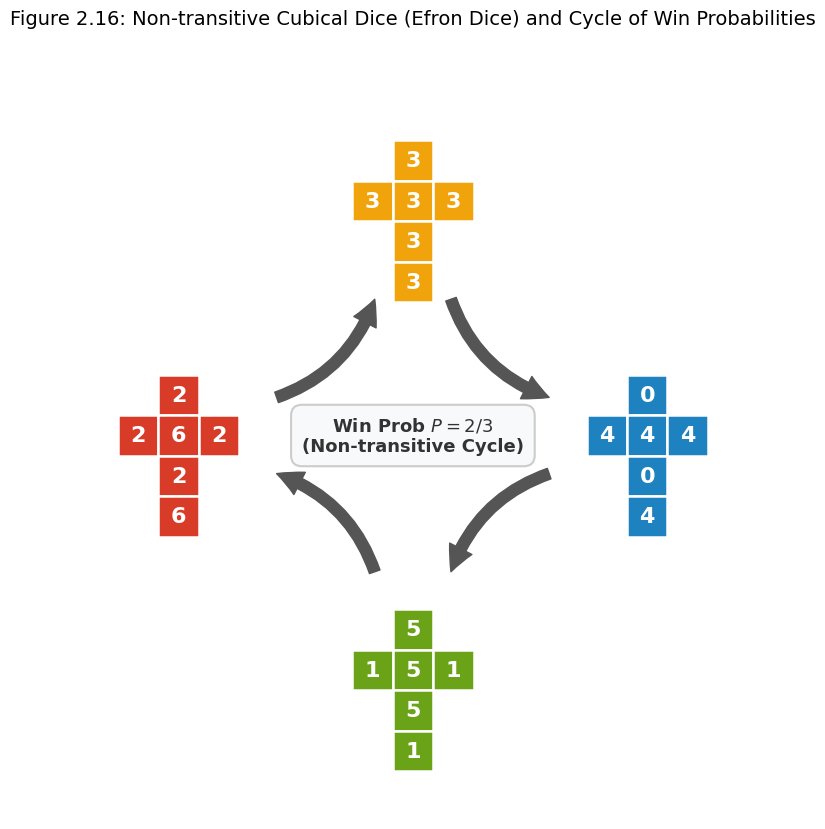

In [4]:
# Figure 2.16 完全再現: 4つの非推移的立方体サイコロ (Efron Dice) の展開図とサイクル
fig, ax = plt.subplots(figsize=(8, 9))

# サイコロの面設定 (クロス型展開図: 上, 左, 中央, 右, 下, 最下)
dice_config = {
    'Yellow': {
        'center': (0.0, 2.2),
        'color': '#f1a30b',
        'faces': [3, 3, 3, 3, 3, 3]
    },
    'Blue': {
        'center': (2.2, 0.0),
        'color': '#1f82c0',
        'faces': [0, 4, 4, 4, 0, 4]  # 上:0, 左:4, 中:4, 右:4, 下:0, 最下:4
    },
    'Green': {
        'center': (0.0, -2.2),
        'color': '#6aa317',
        'faces': [5, 1, 5, 1, 5, 1]  # 上:5, 左:1, 中:5, 右:1, 下:5, 最下:1
    },
    'Red': {
        'center': (-2.2, 0.0),
        'color': '#d83b27',
        'faces': [2, 2, 6, 2, 2, 6]  # 上:2, 左:2, 中:6, 右:2, 下:2, 最下:6
    }
}

s = 0.38  # 正方形の1辺の長さ

def draw_flattened_die(ax, cx, cy, color, faces):
    # クロス型の正方形オフセット (x_offset, y_offset)
    # faces: [top, left, center, right, bottom, bottom2]
    offsets = [
        (0, 1),    # Top
        (-1, 0),   # Left
        (0, 0),    # Center
        (1, 0),    # Right
        (0, -1),   # Bottom
        (0, -2)    # Bottom-most
    ]
    for (ox, oy), num in zip(offsets, faces):
        rect = patches.Rectangle(
            (cx + (ox - 0.5) * s, cy + (oy - 0.5) * s), s, s,
            facecolor=color, edgecolor='white', lw=1.8, zorder=3
        )
        ax.add_patch(rect)
        ax.text(cx + ox * s, cy + oy * s, str(num),
                color='white', fontsize=16, ha='center', va='center', weight='bold', zorder=4)

# 各サイコロの展開図を描画
for name, cfg in dice_config.items():
    draw_flattened_die(ax, cfg['center'][0], cfg['center'][1], cfg['color'], cfg['faces'])

# サイクル矢印を描画 (円弧矢印)
arc_radius = 1.35
arrow_angles = [
    (75, 15),    # Yellow -> Blue
    (-15, -75),  # Blue -> Green
    (-105, -165),# Green -> Red
    (165, 105)   # Red -> Yellow
]

for theta1, theta2 in arrow_angles:
    rad1 = np.radians(theta1)
    rad2 = np.radians(theta2)
    x1, y1 = arc_radius * np.cos(rad1), arc_radius * np.sin(rad1)
    x2, y2 = arc_radius * np.cos(rad2), arc_radius * np.sin(rad2)
    
    arrow = patches.FancyArrowPatch(
        (x1, y1), (x2, y2),
        connectionstyle="arc3,rad=0.25",
        color='#555555',
        arrowstyle='simple,head_width=18,head_length=18,tail_width=8',
        zorder=2
    )
    ax.add_patch(arrow)

# 勝率テキストの注記
ax.text(0.0, 0.0, 'Win Prob $P = 2/3$\n(Non-transitive Cycle)', ha='center', va='center',
        fontsize=13, weight='bold', color='#333333',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#cccccc', lw=1.5))

ax.set_xlim([-3.6, 3.6])
ax.set_ylim([-3.6, 3.6])
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Figure 2.16: Non-transitive Cubical Dice (Efron Dice) and Cycle of Win Probabilities", fontsize=14, pad=20)

save_plot(fig, 'result/fig2_16_efron_dice.png')
plt.show()


---
### まとめ: 第2章 2.6節で学んだ最重要概念

1. **ベイズの定理によるパラメータ表現**:
   $$p(\mathbf{w}|\mathcal{D}) = \frac{p(\mathcal{D}|\mathbf{w})p(\mathbf{w})}{p(\mathcal{D})}$$
   不確実性を確率分布として表現し、観測データにより事前確信を更新。
2. **正則化とMAP推定の等価性**:
   等方ガウス事前分布 $p(\mathbf{w}) = \mathcal{N}(\mathbf{0}, s^2 \mathbf{I})$ のもとでのMAP推定は、正則化パラメータ $\lambda = \frac{\sigma^2}{s^2}$ を持つRidge回帰と完全に等価。
3. **完全ベイズ予測分布**:
   $$p(t|x, \mathcal{D}) = \int p(t|x, \mathbf{w}) p(\mathbf{w}|\mathcal{D}) d\mathbf{w}$$
   パラメータ空間の積分（周辺化）により、過学習を自然に回避し、データが疎な領域で不確実性を適切に表現。
4. **確率の非推移性 (Figure 2.16)**:
   決定論的数値と異なり、確率変数においては $A > B, B > C, C > D$ であっても $A > D$ とはならず、勝率 $2/3$ の非推移的サイクルが存在する。
